<a href="https://colab.research.google.com/github/manidharc7/ISI-2026-Group1-Property-Valuation/blob/main/ISI_Project_Property_Valuation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## M0 — Setup
# !pip install -q scikit-learn pandas numpy matplotlib joblib groq

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("setup ok")

setup ok


In [3]:
## M1 — Load Data
df_raw = pd.read_csv("AmesHousing.csv")

print("shape:", df_raw.shape)
print(df_raw.columns.tolist()[:12])

df_raw[["Overall Qual", "Gr Liv Area", "Year Built", "Neighborhood", "SalePrice"]].head()

shape: (2930, 82)
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config']


,Overall Qual,Gr Liv Area,Year Built,Neighborhood,SalePrice
0,6,1656,1960,NAmes,215000
1,5,896,1961,NAmes,105000
2,6,1329,1958,NAmes,172000
3,7,2110,1968,NAmes,244000
4,5,1629,1997,Gilbert,189900


In [4]:
## M2 — Outlier Removal + Feature Selection
before = len(df_raw)
df = df_raw[df_raw["Gr Liv Area"] <= 4000].copy()
print(f"dropped {before - len(df)} outliers; rows now {len(df)}")

NUMERIC = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Cars",
    "Garage Area",
    "Year Built",
    "Year Remod/Add",
    "Full Bath",
    "TotRms AbvGrd",
    "1st Flr SF",
    "Lot Area",
    "Fireplaces",
    "Bedroom AbvGr",
]

CATEGORICAL = ["Neighborhood"]
TARGET = "SalePrice"
FEATURES = NUMERIC + CATEGORICAL

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("X:", X.shape, " y:", y.shape)
print("SalePrice in X?", TARGET in X.columns)

dropped 5 outliers; rows now 2925
X: (2925, 14)  y: (2925,)
SalePrice in X? False


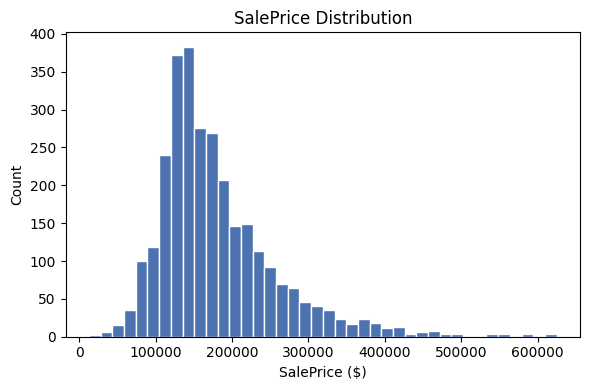

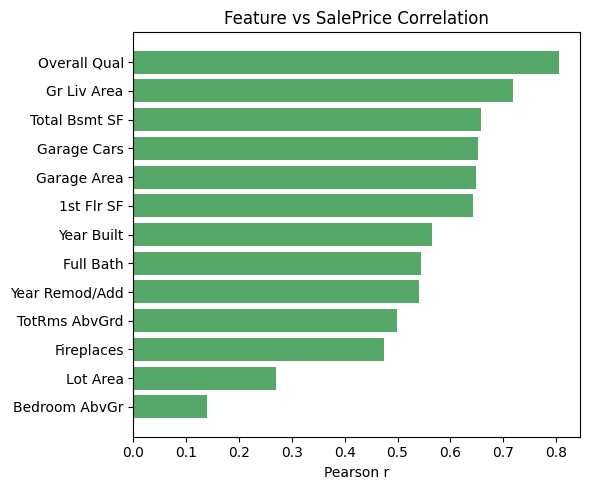

Overall Qual      0.81
Gr Liv Area       0.72
Total Bsmt SF     0.66
Garage Cars       0.65
Garage Area       0.65
1st Flr SF        0.64
Year Built        0.57
Full Bath         0.54
Year Remod/Add    0.54
TotRms AbvGrd     0.50
Fireplaces        0.47
Lot Area          0.27
Bedroom AbvGr     0.14
Name: SalePrice, dtype: float64


In [5]:
## M3 — EDA (Price Distribution)
plt.figure(figsize=(6, 4))
plt.hist(y, bins=40, color="#4C72B0", edgecolor="white")
plt.title("SalePrice Distribution")
plt.xlabel("SalePrice ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

corr = df[NUMERIC + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(6, 5))
plt.barh(corr.index, corr.values, color="#55A868")
plt.title("Feature vs SalePrice Correlation")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

print(corr.sort_values(ascending=False).round(2))

In [6]:
## M4 — Preprocessing / Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train={len(X_train)} test={len(X_test)}")

num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUMERIC),
    ("cat", cat_pipe, CATEGORICAL)
])

print("preprocessor ready")

train=2340 test=585
preprocessor ready


In [8]:
## M5 — Linear Regression Baseline
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

lr_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_metrics = {
    "rmse": rmse(y_test, lr_pred),
    "mae": float(mean_absolute_error(y_test, lr_pred)),
    "r2": float(r2_score(y_test, lr_pred))
}

print(f"RMSE=${lr_metrics['rmse']:,.0f}  MAE=${lr_metrics['mae']:,.0f}  R²={lr_metrics['r2']:.3f}")

RMSE=$29,581  MAE=$19,153  R²=0.877


In [9]:
## M6 — Random Forest
#%%
rf_model = Pipeline([
    ("prep",preprocessor),
    ("model",RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_model.fit(X_train,y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = {
    "rmse": rmse(y_test, rf_pred),
    "mae": float(mean_absolute_error(y_test, rf_pred)),
    "r2": float(r2_score(y_test, rf_pred))
}
print(f"RMSE=${rf_metrics['rmse']:,.0f}  MAE=${rf_metrics['mae']:,.0f}  R²={rf_metrics['r2']:.3f}")

RMSE=$24,011  MAE=$15,547  R²=0.919


            model      RMSE       MAE    R2
Linear Regression 29581.266 19152.744 0.877
    Random Forest 24010.957 15546.538 0.919
winner: Random Forest
final_model -> Random Forest


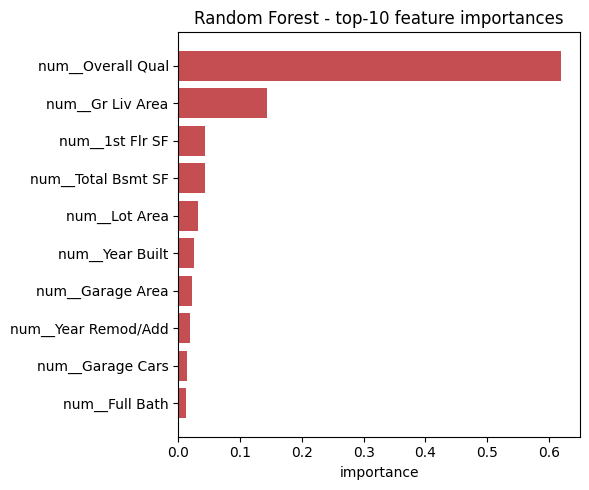

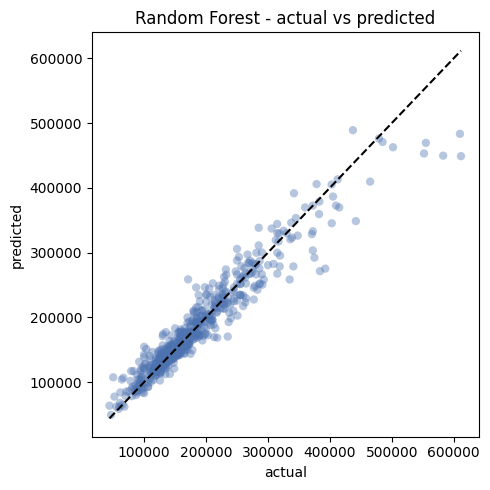

In [10]:
## M7 — Model Comparison
#%%
eval_table = pd.DataFrame({
 "model": ["Linear Regression", "Random Forest"],
 "RMSE": [lr_metrics["rmse"], rf_metrics["rmse"]],
 "MAE": [lr_metrics["mae"], rf_metrics["mae"]],
 "R2": [lr_metrics["r2"], rf_metrics["r2"]],
})
winner = "Random Forest" if rf_metrics["r2"] > lr_metrics["r2"] else "Linear Regression"
print(eval_table.round(3).to_string(index=False)); print("winner:", winner)

final_model = rf_model if winner == "Random Forest" else lr_model
print("final_model ->", winner)

feat_names = rf_model.named_steps["prep"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_
top = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(10)
plt.figure(figsize=(6,5))
plt.barh(top.index[::-1], top.values[::-1], color="#C44E52")
plt.title("Random Forest - top-10 feature importances"); plt.xlabel("importance")
plt.tight_layout(); plt.show()
plt.figure(figsize=(5,5))
plt.scatter(y_test, rf_pred, alpha=0.4, color="#4C72B0", edgecolor="none")
lims = [y_test.min(), y_test.max()]; plt.plot(lims, lims, "k--")
plt.title("Random Forest - actual vs predicted"); plt.xlabel("actual"); plt.ylabel("predicted");
plt.tight_layout(); plt.show()

In [11]:
## M7b — Top 10% Expensive Houses Error Analysis
#%%

threshold = y_test.quantile(0.90)

expensive_mask = y_test >= threshold
normal_mask = y_test < threshold

print("Top 10% SalePrice threshold:", threshold)
print("Number of expensive houses:", expensive_mask.sum())

Top 10% SalePrice threshold: 285000.0
Number of expensive houses: 60


In [12]:
## M7b — Top 10% Expensive Houses Error Analysis (cont.)
#%%
normal_mae = mean_absolute_error(y_test[normal_mask],rf_pred[normal_mask])
expensive_mae = mean_absolute_error(y_test[expensive_mask],rf_pred[expensive_mask])

normal_rmse = rmse(y_test[normal_mask], rf_pred[normal_mask])
expensive_rmse = rmse(y_test[expensive_mask],rf_pred[expensive_mask])

normal_r2 = r2_score(y_test[normal_mask],rf_pred[normal_mask])
expensive_r2 = r2_score(y_test[expensive_mask],rf_pred[expensive_mask])

percentage_error = (np.abs(y_test-rf_pred)/y_test)*100
normal_percentage_error = percentage_error[normal_mask]
expensive_percentage_error = percentage_error[expensive_mask]
print("Remaining 90%:")
print("MAE:", normal_mae)
print("RMSE:", normal_rmse)
print("R²:", normal_r2)
print("normal percentage error: ",normal_percentage_error.mean())

print("\nTop 10% expensive houses:")
print("MAE:", expensive_mae)
print("RMSE:", expensive_rmse)
print("R²:", expensive_r2)
print("expensive percentage error:",expensive_percentage_error.mean())

Remaining 90%:
MAE: 12831.326727588812
RMSE: 17596.61027069993
R²: 0.8792519569817195
normal percentage error:  8.696187642726017

Top 10% expensive houses:
MAE: 39304.640222222224
RMSE: 53960.847394047836
R²: 0.5805844804556
expensive percentage error: 9.935404219105012


In [13]:
## M8 — Valuation App
#%%
defaults = {c: float(X[c].median()) for c in NUMERIC}
defaults["Neighborhood"] = X["Neighborhood"].mode().iloc[0]
neighborhoods = sorted(X["Neighborhood"].unique())

def value_house(features):
 row = {**defaults, **{k: v for k, v in features.items() if k in FEATURES}}
 return float(final_model.predict(pd.DataFrame([row])[FEATURES])[0])

my_house = {"Overall Qual": 7, "Gr Liv Area": 1500, "Year Built": 2005,
 "Garage Cars": 2, "Full Bath": 2, "Bedroom AbvGr": 3}
print(f"single-house estimate: ${value_house(my_house):,.0f}")

batch = X_test.head(5).copy()
batch["predicted_price"] = final_model.predict(batch)
print(batch[["Overall Qual","Gr Liv Area","Neighborhood","predicted_price"]].to_string(index=False))

single-house estimate: $188,295
 Overall Qual  Gr Liv Area Neighborhood  predicted_price
            6         1456      NPkVill    147271.577143
            9         2728      NridgHt    488953.836667
            7         1665      Somerst    202667.603333
            6         1252      ClearCr    170255.320000
            5         1904        NAmes    147434.906667


In [15]:
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get("Expln_Value")
!pip install -q groq
from groq import Groq

client = Groq()
GROQ_MODEL = "llama-3.3-70b-versatile"

drivers = [n.replace("num__","").replace("cat__","") for n in top.index[:4]]

def explain_valuation(house, predicted_price, drivers):
    facts = "\n".join(f"- {k}: {v}" for k, v in house.items())
    prompt = (
        f"You are a property valuation assistant. A machine learning model has "
        f"already estimated this house at ${predicted_price:,.0f}. "
        f"Do NOT change or re-estimate the price. "
        f"In 3-4 sentences explain to a buyer why it lands near that figure "
        f"using its attributes and the model's main drivers ({', '.join(drivers)})."
        f"\n\nAttributes:\n{facts}"
    )
    resp = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.4
    )
    return resp.choices[0].message.content.strip()

sample_price = value_house(my_house)
print(f"Predicted price: ${sample_price:,.0f}")
print("\nExplanation:")
print(explain_valuation(my_house, sample_price, drivers))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 7.0 MB/s eta 0:00:00
Predicted price: $188,295

Explanation:
The estimated price of $188,295 for this house is largely driven by its above-average overall quality, rated 7 out of a possible scale, which suggests a well-built and well-maintained property. The generous living area of 1500 square feet, combined with a decent-sized basement, provides ample space for residents, contributing to its value. Additionally, the three bedrooms above grade and two full bathrooms offer a comfortable living arrangement, aligning with the model's estimate. These attributes, particularly the overall quality and living area, are key drivers of the model's valuation, resulting in a price point of $188,295.
